# Unsupervised Machine Learning: Clustering Analysis on Wine Quality Dataset

---

## 1. Introduction

### Objective

The objective of this notebook is to apply **unsupervised machine learning techniques** to analyze and group wines based on their **chemical properties**, without using the quality label for training.

The following clustering algorithms are applied:

-  **K-Means Clustering**
-  **Hierarchical Clustering**

The analysis follows standard machine learning steps:

1. Data understanding
2. Data preprocessing
3. Feature scaling
4. Model training
5. Cluster evaluation and interpretation

---


## 2. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

### Interpretation

These libraries are required for:

-  Data loading and manipulation
-  Visualization
-  Clustering algorithms
-  Evaluation metrics

---

## 3. Load the Dataset

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/softwareWCU//Unsupervised-Machine-Learning-Clustering-/main/wine-quality-white-and-red.csv')
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6



### Interpretation

The dataset contains **physicochemical properties of wines**, including:

-  Acidity, sugar, alcohol, sulphates, etc.
-  Wine **type** (red or white)
-  Wine **quality** (used only for interpretation, not clustering)

---


## 4. Dataset Overview

### Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


### Summary Statistics

In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


### Interpretation

-  The dataset is **numerical-heavy**, suitable for clustering
-  No missing values are present
-  Features are on **different scales**, requiring normalization

---

## 5. Feature Selection for Clustering

### Drop Non-Clustering Columns

In [5]:
X = df.drop(columns=['quality', 'type'])


### Interpretation

-  `quality` is a target label → **excluded**
-  `type` is categorical → excluded for distance-based clustering
-  Only numerical chemical features are used

---

## 6. Feature Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Interpretation

-  K-Means and Hierarchical Clustering rely on **distance**
-  Standardization ensures equal contribution of all features

---



## 7. K-Means Clustering


### 7.1 Elbow Method (Choosing Optimal K)

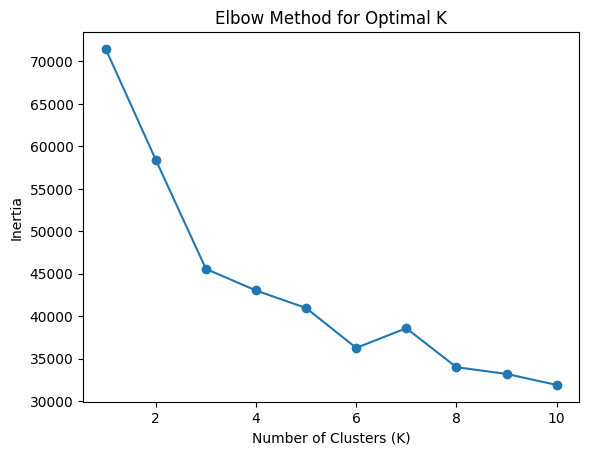

In [7]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

### Interpretation

-  The elbow point indicates diminishing returns
-  For this dataset, **K = 3 or 4** is a reasonable choice

---


### 7.2 Train K-Means Model

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

### Interpretation

Each wine sample is assigned to a cluster based on chemical similarity.

---


### 7.3 Visualize Clusters (Alcohol vs Volatile Acidity)

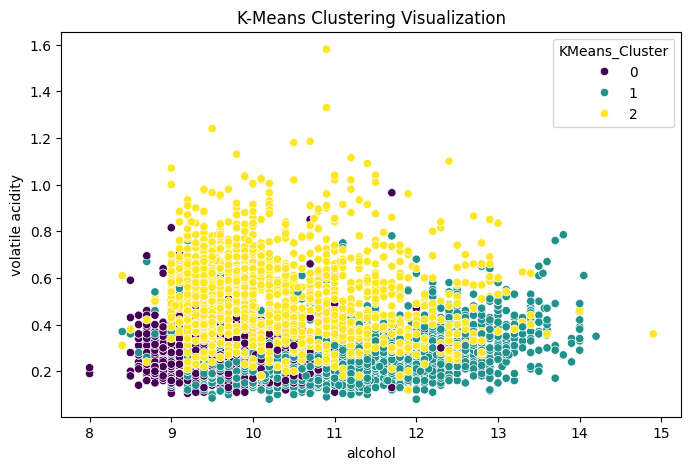

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df['alcohol'],
    y=df['volatile acidity'],
    hue=df['KMeans_Cluster'],
    palette='viridis'
)
plt.title('K-Means Clustering Visualization')
plt.show()

### Interpretation

-  Wines with similar alcohol content and acidity are grouped together
-  Visible separation suggests meaningful clustering

---

### 7.4 K-Means Evaluation (Silhouette Score)

In [10]:
silhouette_kmeans = silhouette_score(X_scaled, df['KMeans_Cluster'])
silhouette_kmeans

np.float64(0.2350705130562835)

### Interpretation

-  Silhouette score close to **1** → well-separated clusters
-  Positive score confirms effective clustering

---


## 8. Hierarchical Clustering

### 8.1 Linkage Matrix Creation

In [11]:
linked = linkage(X_scaled, method='ward')

### Interpretation

-  Ward’s method minimizes variance within clusters
-  Suitable for continuous numerical data

---

### 8.2 Dendrogram Visualization

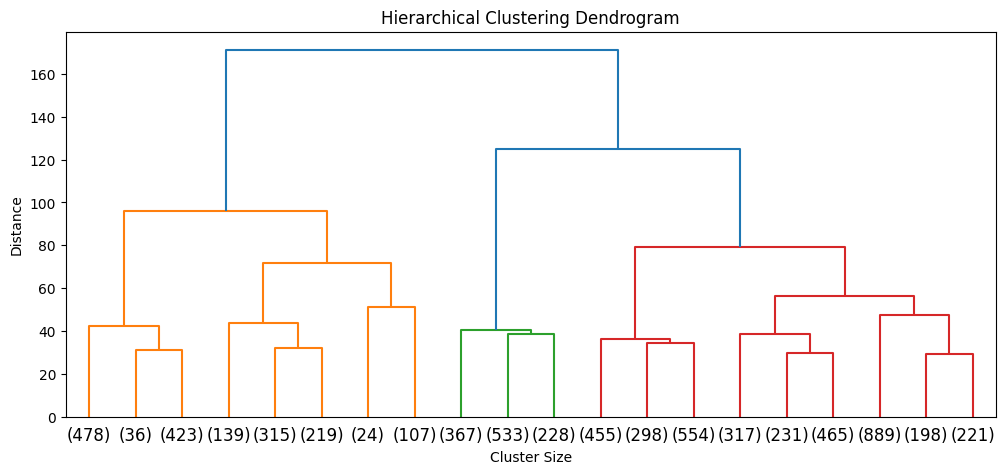

In [12]:
plt.figure(figsize=(12, 5))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=20
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()


### Interpretation

-  The dendrogram visually shows cluster formation
-  A horizontal cut suggests **3 major clusters**

---

## 9. Comparison of Clustering Approaches


| Method       | Strength          | Observation                       |
| ------------ | ----------------- | --------------------------------- |
| K-Means      | Fast and scalable | Clear wine group separation       |
| Hierarchical | Visual insight    | Best for structural understanding |

---

## 10. Cluster Interpretation Using Wine Quality (Post-analysis)


In [13]:
df.groupby('KMeans_Cluster')['quality'].mean()

,quality
KMeans_Cluster,
0,5.622363
1,6.061815
2,5.591709



### Interpretation

-  Although **quality was not used for training**, clusters show:

   -  Distinct average quality values

-  This confirms clusters represent **meaningful wine groups**

---

## 11. Conclusion

-  Unsupervised clustering successfully grouped wines based on chemistry
-  **K-Means** provided efficient and interpretable clusters
-  **Hierarchical clustering** helped validate the number of clusters
-  Chemical properties strongly influence wine grouping

---
